In [3]:
# 告诉 Colab 安装 mediapipe
!pip install mediapipe opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [4]:
import cv2
import urllib.request
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.patches import cv2_imshow

# 1. 下载 Google 官方最新预训练的姿态识别模型文件 (.task 格式)
print("正在下载模型，请稍等...")
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
urllib.request.urlretrieve(model_url, "pose_landmarker.task")

# 2. 初始化最新的 Tasks API 姿态识别器
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False)
detector = vision.PoseLandmarker.create_from_options(options)

# 3. 读取你刚才上传的图片
image_path = 'test.jpg' # 确保你的图片名字依然是 test.jpg
cv2_image = cv2.imread(image_path)
h, w, c = cv2_image.shape # 获取图片的宽和高
# 转换为新版 MediaPipe 需要的特殊 Image 对象格式
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(cv2_image, cv2.COLOR_BGR2RGB))

# 4. 执行检测！
detection_result = detector.detect(mp_image)

# 5. 手动绘制骨架 (我们自己用 OpenCV 画，完全摆脱旧版限制)
# 这是人体 33 个关键点的标准连线规则
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10),
    (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), (11, 23),
    (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), (27, 29),
    (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
]

if detection_result.pose_landmarks:
    print("\n太棒了！最新版的 Tasks API 成功检测到骨骼点！")
    # 取出检测到的第一个人的骨骼数据
    landmarks = detection_result.pose_landmarks[0]

    # 将模型输出的比例坐标，乘以图片的宽高，算出真实的像素坐标点
    points = []
    for landmark in landmarks:
        px, py = int(landmark.x * w), int(landmark.y * h)
        points.append((px, py))
        # 用 OpenCV 画出关节点 (绿色圆圈)
        cv2.circle(cv2_image, (px, py), 5, (0, 255, 0), -1)

    # 用 OpenCV 画出骨骼连线 (红色线段)
    for connection in POSE_CONNECTIONS:
        start_idx, end_idx = connection
        cv2.line(cv2_image, points[start_idx], points[end_idx], (0, 0, 255), 2)

    # 显示最终结果
    cv2_imshow(cv2_image)
else:
    print("\n哎呀，没检测到人，换一张清晰点的全身照试试？")

正在下载模型，请稍等...


AttributeError: 'NoneType' object has no attribute 'shape'

计算完成！左臂手肘当前的弯曲角度是: 109度


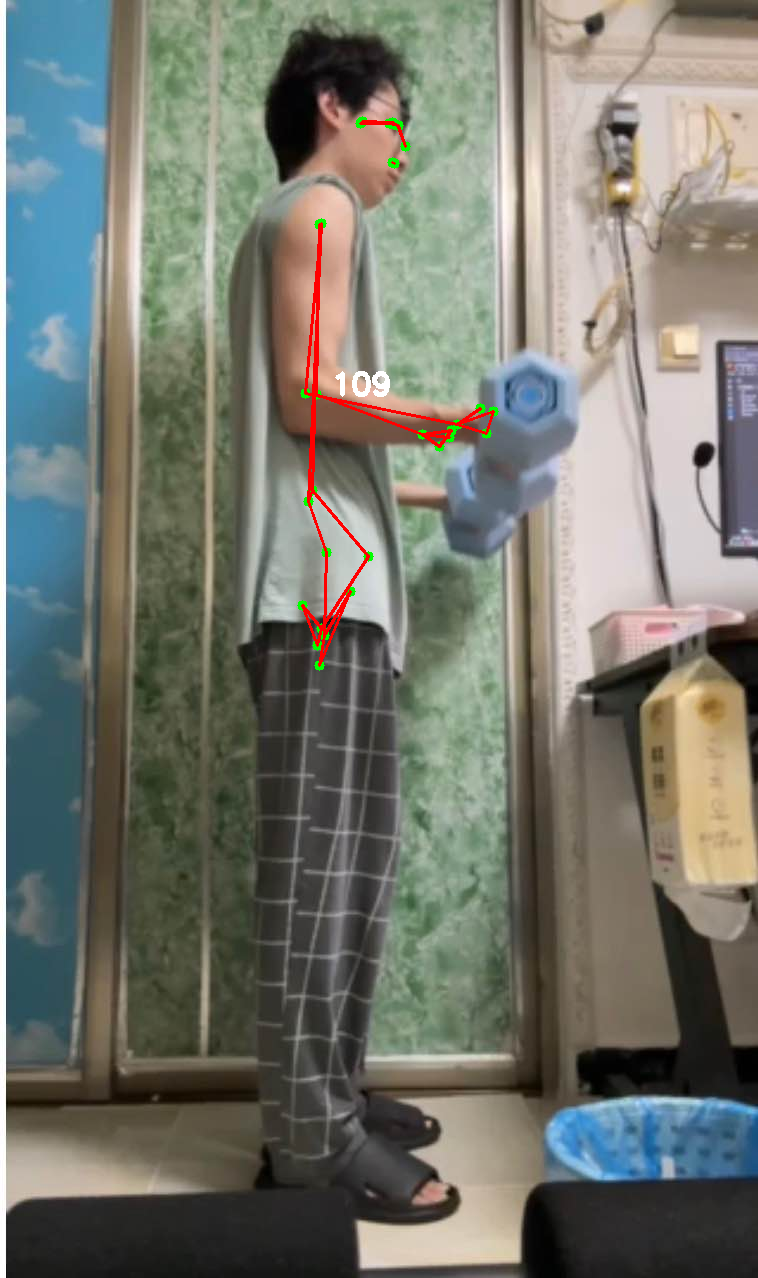

In [ ]:
import math
import cv2
from google.colab.patches import cv2_imshow

# 1. 之前定义的计算角度的函数 (保持不变)
def calculate_angle(a, b, c):
    radians = math.atan2(c[1] - b[1], c[0] - b[0]) - math.atan2(a[1] - b[1], a[0] - b[0])
    angle = abs(radians * 180.0 / math.pi)
    if angle > 180.0:
        angle = 360 - angle
    return int(angle)

# 2. 【关键修改】提取左臂的三个关键点
shoulder = points[11] # 左肩
elbow = points[13]    # 左肘 (顶点)
wrist = points[15]    # 左腕

# 3. 调用函数计算手肘的角度
elbow_angle = calculate_angle(shoulder, elbow, wrist)
print(f"计算完成！左臂手肘当前的弯曲角度是: {elbow_angle}度")

# 4. 把角度数值写在图片上的手肘位置！
# 同样用白色粗体字，写在手肘坐标旁边
cv2.putText(cv2_image, str(elbow_angle),
            (elbow[0] + 15, elbow[1]),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)

# 5. 再次显示更新后的图片
cv2_imshow(cv2_image)

In [19]:
import cv2
import math
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. 计算角度的函数
def calculate_angle(a, b, c):
    radians = math.atan2(c[1] - b[1], c[0] - b[0]) - math.atan2(a[1] - b[1], a[0] - b[0])
    angle = abs(radians * 180.0 / math.pi)
    if angle > 180.0:
        angle = 360 - angle
    return int(angle)

# 2. 初始化检测器
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(base_options=base_options, output_segmentation_masks=False)
detector = vision.PoseLandmarker.create_from_options(options)

# 3. 初始化变量
counter = 0
stage = None
feedback = "Good Form"  # 初始反馈语
elbow_positions = []    # 用于存储一周期内手肘的 X 坐标，判断是否摇摆

# --- 修改这里：选择你要测试的视频文件 ---
input_video_path = 'video_frswin.mp4'  # 建议先拿你录的“作弊视频”测试
output_video_path = 'frswin_analysis_output.mp4'

cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

print(f"正在分析视频: {input_video_path}...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    detection_result = detector.detect(mp_image)

    angle = 0
    if detection_result.pose_landmarks:
        landmarks = detection_result.pose_landmarks[0]

        # 获取右侧关键点坐标（已修复语法错误）
        shoulder = [int(landmarks[12].x * width), int(landmarks[12].y * height)]
        elbow = [int(landmarks[14].x * width), int(landmarks[14].y * height)]
        wrist = [int(landmarks[16].x * width), int(landmarks[16].y * height)]

        # 计算手肘角度
        angle = calculate_angle(shoulder, elbow, wrist)

        # --- 核心改进：手肘稳定性分析 ---
        elbow_positions.append(elbow[0])  # 记录当前帧手肘的 X 坐标

        # 计数逻辑
        if angle > 140:
            stage = "down"
        if angle < 50 and stage == "down":
            stage = "up"
            counter += 1

            # 当完成一次动作时，分析这一组手肘 X 坐标的波动
            x_movement = max(elbow_positions) - min(elbow_positions)

            if x_movement > 80:  # 手肘晃动超过 40 像素则警告
                feedback = "WARNING: KEEP ELBOW STILL!"
            else:
                feedback = "Good Form!"

            elbow_positions = []  # 重置，开始下一周期的监测

        # 绘制骨骼
        cv2.line(frame, tuple(shoulder), tuple(elbow), (255, 255, 255), 3)
        cv2.line(frame, tuple(elbow), tuple(wrist), (255, 255, 255), 3)
        for p in [shoulder, elbow, wrist]:
            cv2.circle(frame, tuple(p), 8, (0, 255, 0), -1)

    # --- 界面增强：绘制专业数据面板 ---
    # 顶部状态栏（显示次数和角度）
    cv2.rectangle(frame, (0, 0), (width, 80), (0, 0, 0), -1)
    cv2.putText(frame, f"REPS: {counter}", (30, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)
    cv2.putText(frame, f"ANGLE: {angle}", (280, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)

    # --- 底部居中显示反馈文字（新增）---
    if feedback:
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 3
        color = (0, 0, 255) if "WARNING" in feedback else (0, 255, 0)

        # 获取文字尺寸，用于精确居中
        (text_width, text_height), baseline = cv2.getTextSize(feedback, font, font_scale, thickness)

        # 计算居中坐标
        text_x = (width - text_width) // 2
        text_y = height - 30  # 距离底部 30 像素，可根据需要调整

        cv2.putText(frame, feedback, (text_x, text_y), font, font_scale, color, thickness)

    # 如果正在警告，画面中央也闪烁一下提示
    if "WARNING" in feedback and angle < 90:
        cv2.putText(frame, "FORM ERROR!", (width//2 - 150, height//2),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

    out.write(frame)

cap.release()
out.release()
print(f"分析完成！结果已保存至: {output_video_path}")

正在分析视频: video_frswin.mp4...
分析完成！结果已保存至: frswin_analysis_output.mp4
